In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import time
import torch

c:\Users\Admin\Desktop\ip\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODELO_PATH = r"C:\Users\Admin\Desktop\models\Teste\Qwen3-4B-Base\BASE"

modelo = AutoModelForCausalLM.from_pretrained (MODELO_PATH, device_map = "cpu")

tokenizer = AutoTokenizer.from_pretrained (MODELO_PATH)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 2132.97it/s]


<h1> Time to First Token </h1>

processa prompt (prefill) 
constrói KV cache
gera primeiro token
retorna output

In [31]:
TtFT = []

prompt = "O que sabes da empresa Infraestruturas de Portugal ?"

input = tokenizer (prompt, return_tensors = "pt")
#print (len(input["input_ids"])) #TESTE -> 14

for _ in range (35):
    
    t0 = time.perf_counter()
    tokens = modelo.generate (**input, max_new_tokens = 1)

    t1 = time.perf_counter()

    delta = t1 - t0
    TtFT.append(delta)


[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_toke

In [32]:
print (TtFT)
print (len(TtFT))

[1.7920844000000216, 1.5263016999999763, 1.5218257999999878, 1.5380958999999166, 1.5348765999999614, 1.536232899999959, 1.5545011000001523, 1.5881632000000536, 1.7942344999999023, 1.7695811000000958, 1.7308573000000251, 1.7200886000000537, 1.7258646000000226, 1.7335607999998501, 1.734983100000136, 1.6029393000001164, 1.564358299999867, 1.5594427000000906, 1.5527870000000803, 1.5733338000000003, 1.552014900000131, 1.5499601999999868, 1.5824895000000652, 1.5702616999999464, 1.5492987000000085, 1.5469837000000553, 1.546567399999958, 1.555822600000056, 1.5821260000000166, 1.5697606999999607, 1.5425242999999682, 1.5750368999999864, 1.5775123000000804, 1.557877499999904, 1.5320438999999624]
35


# Latencia Total


Calculo do tempo total desde tokenizer ate geracao total

In [40]:
Lat = []

prompt = "O que sabes da empresa Infraestruturas de Portugal ?"

for i in range (15):

    t0 = time.perf_counter()
    input = tokenizer (prompt, return_tensors = "pt")

    tokens = modelo.generate (**input, max_new_tokens = 100)

    texto = tokenizer.decode (tokens[0])

    #print (texto)
    t1 = time.perf_counter()

    delta = t1 - t0
    Lat.append(delta)
    

[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_toke

In [41]:
print (Lat)

[28.845445200000086, 30.20715549999977, 29.162379200000032, 29.513841799999682, 28.60348789999989, 28.970935499999996, 29.597843399999874, 28.55963470000006, 29.222640899999988, 29.1251771000002, 28.00827990000016, 28.10415779999994, 28.28073039999981, 28.206465299999763, 28.289368900000227]


# Throughput

### Prefill = Prompt Processing

### Decode = Token Processing


In [ ]:
throughput = {
    'Prefill': [],
    "Decode": []
}

prompt = "O que sabes da empresa Infraestruturas de Portugal ?"

for i in range (15):

    t0 = time.perf_counter()
    input = tokenizer (prompt, return_tensors = "pt")

    tokens = modelo.generate (**input, max_new_tokens = 100)

    texto = tokenizer.decode (tokens[0])

    #print (texto)
    t1 = time.perf_counter()

    delta = t1 - t0
    Lat.append(delta)
    

In [ ]:
import torch.nn.functional as F

prompt = "O que sabes da empresa Infraestruturas de Portugal ?"

input = tokenizer (prompt, return_tensors = "pt")
#print (len(input["input_ids"])) #TESTE -> 14

input_ids = input['input_ids']


for _ in range (100):

    #PREFILL
    logits = modelo (input_ids = input_ids)
    logits = logits [:, -1, :]


    #DECODE
    probs = F.softmax (logits, dim = -1)

    next_token = torch.multinomial (probs, num_samples = 1)

    prev = torch.cat ([input_ids, next_token], dim = 1)



CausalLMOutputWithPast(loss=None, logits=tensor([[[ 6.0312,  9.6875,  5.5938,  ..., -4.0312, -4.0312, -4.0312],
         [ 9.5000,  7.0312,  6.0938,  ..., -1.8672, -1.8672, -1.8672],
         [11.3125, 10.1875,  7.6875,  ...,  1.1641,  1.1641,  1.1641],
         ...,
         [ 7.4062,  4.9688,  1.4766,  ..., -5.6562, -5.6562, -5.6562],
         [20.0000, 17.2500, 14.4375,  ...,  1.0938,  1.0938,  1.0938],
         [17.3750, 17.8750, 15.2500,  ..., -0.7031, -0.7031, -0.7031]]],
       dtype=torch.bfloat16, grad_fn=<UnsafeViewBackward0>), past_key_values=DynamicCache(layers=[DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer,

In [1]:
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

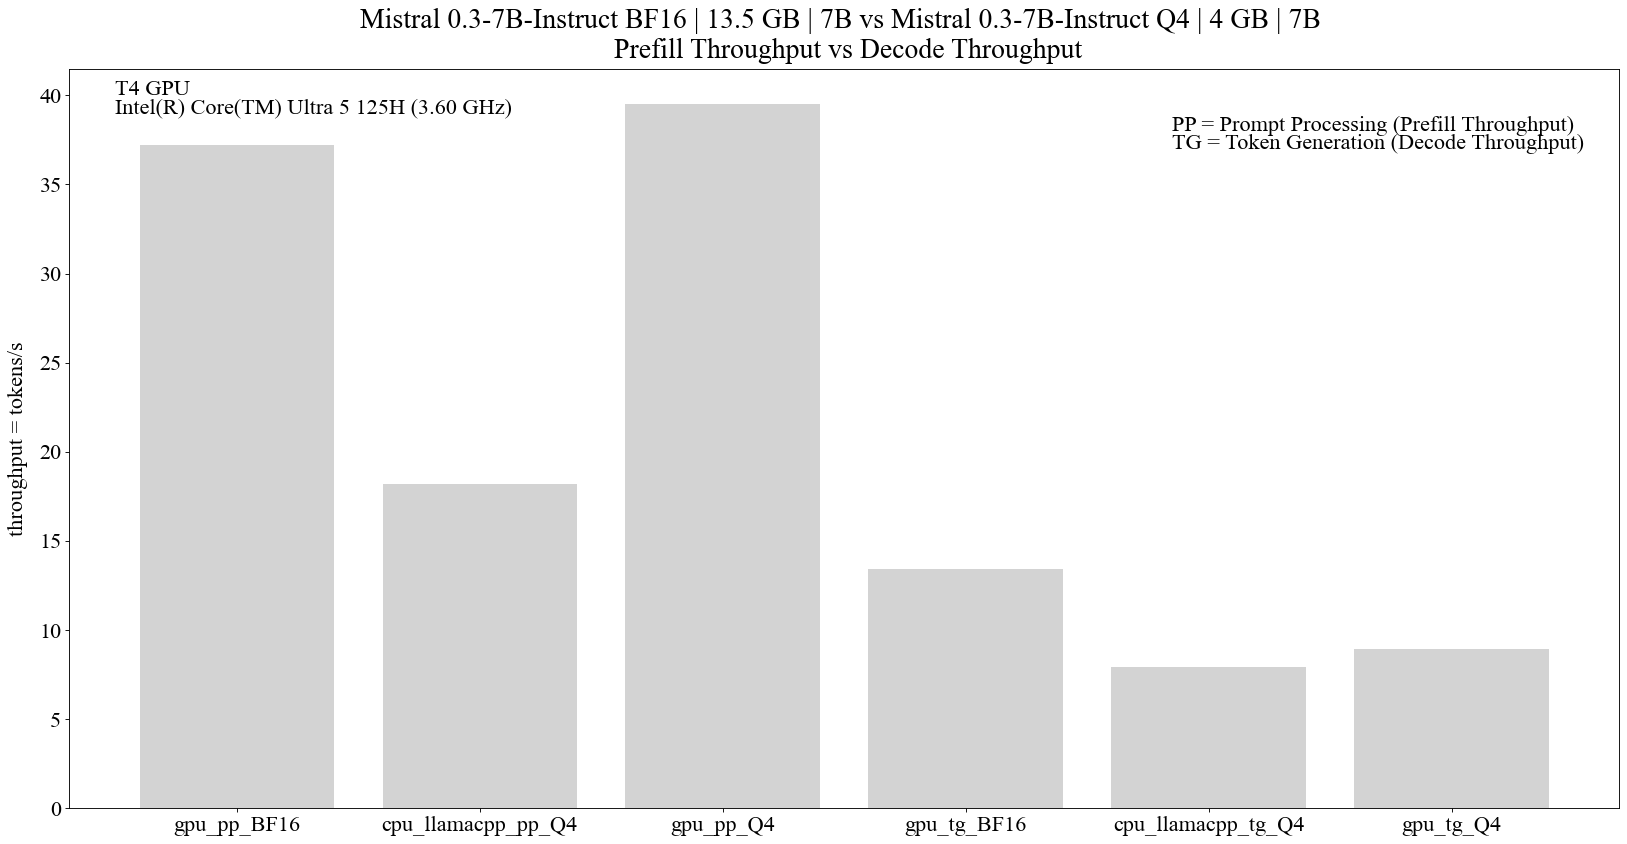

In [ ]:
#Estudo que avalia o modelo Qwen 3 4B Base em vários tipos de Hardware -> CPU, CPU com llama.cpp e GPU
#PP -> Prompt Processing
#TP -> Token Processing

MISTRAL = { #https://github.com/Eliezer-Carvalho
           
    "gpu_pp_BF16": 37.2,
    "cpu_llamacpp_pp_Q4": 18.21,
    "gpu_pp_Q4": 39.5, 
            
    "gpu_tg_BF16": 13.43,
    "cpu_llamacpp_tg_Q4": 7.92,
    "gpu_tg_Q4": 8.94
}


plt.figure (figsize = (25, 12), dpi = 80)
plt.bar (MISTRAL.keys(), MISTRAL.values(), color = "lightgrey")

plt.xticks (size = 20, fontname = "Times New Roman")
plt.yticks (size = 20, fontname = "Times New Roman")

plt.ylabel ("throughput = tokens/s", size = 20, fontname = "Times New Roman", labelpad = 10)

plt.text (-0.5, 40, 'T4 GPU', fontsize = 20, fontname = "Times New Roman")
plt.text (-0.5, 39, 'Intel(R) Core(TM) Ultra 5 125H (3.60 GHz)', fontsize = 20, fontname = "Times New Roman")

plt.text (3.85, 38, 'PP = Prompt Processing (Prefill Throughput)', fontsize = 20, fontname = "Times New Roman")
plt.text (3.85, 37, 'TG = Token Generation (Decode Throughput)', fontsize = 20, fontname = "Times New Roman")

plt.title ("Mistral 0.3-7B-Instruct BF16 | 13.5 GB | 7B vs Mistral 0.3-7B-Instruct Q4 | 4 GB | 7B \n Prefill Throughput vs Decode Throughput", size = 25, pad = 10, fontname = "Times New Roman")

plt.show()